In [34]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [35]:
# Hide logs
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Set seeds
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Data paths
train_dir = '/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset_clean'
img_size = (224, 224)
batch_size = 32

In [36]:
print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# prepare dataset

In [37]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

num_classes = train_generator.num_classes
print(f"Number of classes: {num_classes}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

Found 7200 images belonging to 9 classes.
Found 1800 images belonging to 9 classes.
Number of classes: 9
Training samples: 7200
Validation samples: 1800


# simple CNN model

In [42]:
inputs = keras.Input(shape=(224, 224, 3))

x = layers.Conv2D(32, 3, activation="relu")(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(64, 3, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)

x = GlobalAveragePooling2D()(x)
x = Dense(32, activation="relu")(x)

outputs = Dense(num_classes, activation="softmax", name="predictions")(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Change in case of
model_save_path = "../../ML/Models/very_simple_baseline_model.keras"

checkpoint_cb = ModelCheckpoint(
    model_save_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stopping_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/20


I0000 00:00:1777503471.219792 1458883 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_42384__.48


225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.4853 - loss: 1.5609
Epoch 1: val_loss improved from None to 2.40378, saving model to ../../ML/Models/very_simple_baseline_model.keras

Epoch 1: finished saving model to ../../ML/Models/very_simple_baseline_model.keras
225/225 ━━━━━━━━━━━━━━━━━━━━ 86s 359ms/step - accuracy: 0.6461 - loss: 1.1402 - val_accuracy: 0.1911 - val_loss: 2.4038
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.8647 - loss: 0.4897
Epoch 2: val_loss did not improve from 2.40378
225/225 ━━━━━━━━━━━━━━━━━━━━ 70s 313ms/step - accuracy: 0.8871 - loss: 0.4191 - val_accuracy: 0.2528 - val_loss: 2.4174
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9276 - loss: 0.2748
Epoch 3: val_loss improved from 2.40378 to 1.28571, saving model to ../../ML/Models/very_simple_baseline_model.keras

Epoch 3: finished saving model to ../../ML/Models/very_simple_baseline_model.keras
225/225 ━━━━━━━━━━━━━━━━━━━━ 66s 295ms/step - accuracy: 0.939

# light analysis

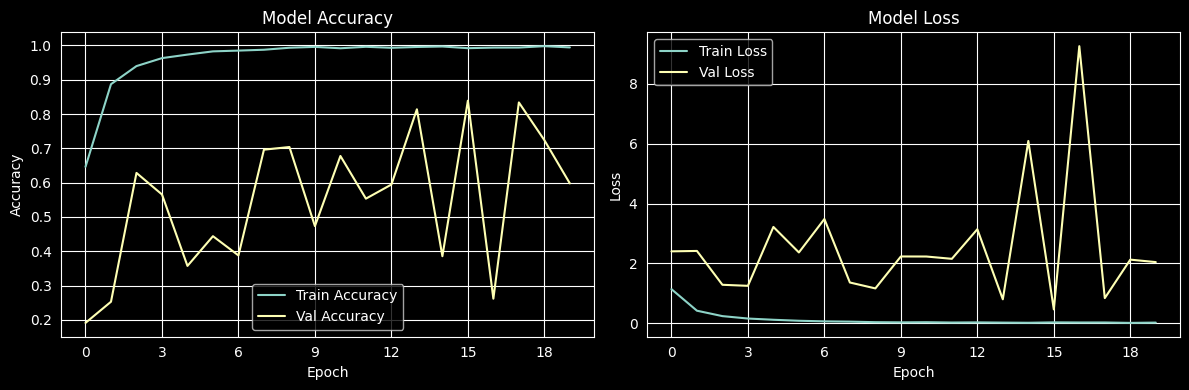

In [48]:
# Visualize training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [44]:
# Results summary
best_val_acc = max(history.history['val_accuracy'])
final_val_acc = history.history['val_accuracy'][-1]

print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"Current best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Final validation accuracy:        {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print("=" * 60)

RESULTS SUMMARY
Current best validation accuracy: 0.8389 (83.89%)
Final validation accuracy:        0.5978 (59.78%)


In [45]:
model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,077 (258.12 KB)

 Trainable params: 21,961 (85.79 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 43,924 (171.58 KB)